## **ML Process - Air Quality**
---
**2 - Data Understanding (EDA)**

In [1]:
# import the requirement library
import yaml
import joblib
import numpy as np
import pandas as pd

# Need to be installed
import seaborn as sns
import scipy.stats as scs
import matplotlib.pyplot as plt

## **1. Configuration File**
---

In [2]:
# Function to load configuration parameter.
def load_config(config_path):
    """
    Load the configuration file (config.yaml).

    Parameters:
    ----------
    path_config : str
        Configuration file location.

    Returns:
    -------
    params : dict
        The configuration parameters.
    """

    # Try to load config.yaml file.
    try:
        with open(config_path, 'r') as file:
            params = yaml.safe_load(file)
    except FileNotFoundError as err:
        raise RuntimeError(f"Configuration file not found in {config_path}")

    return params

In [3]:
# Load the configuration file.
PATH_CONFIG = "../config/config.yaml"
config = load_config(PATH_CONFIG)

In [4]:
# Check the configuration parameters.
config

{'columns_datetime': ['tanggal'],
 'columns_int': ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max'],
 'features': ['stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2'],
 'label': 'category',
 'label_categories': ['BAIK', 'SEDANG', 'TIDAK SEHAT'],
 'label_categories_new': ['BAIK', 'TIDAK BAIK'],
 'object_columns': ['stasiun', 'critical', 'category'],
 'path_joined_data': '../data/interim/joined_dataset.pkl',
 'path_raw_data': '../data/raw/',
 'path_test_set': ['../data/interim/X_test.pkl', '../data/interim/y_test.pkl'],
 'path_train_set': ['../data/interim/X_train.pkl',
  '../data/interim/y_train.pkl'],
 'path_valid_set': ['../data/interim/X_valid.pkl',
  '../data/interim/y_valid.pkl'],
 'path_validated_data': '../data/interim/validated_data.pkl',
 'range_co': [-1, 47],
 'range_no2': [-1, 65],
 'range_o3': [-1, 151],
 'range_pm10': [-1, 179],
 'range_pm25': [-1, 174],
 'range_so2': [-1, 82],
 'range_stasiun': ['DKI1 (Bunderan HI)',
  'DKI2 (Kelapa Gading)',
  'DKI3 (Jagakarsa)',
  'DKI4

## **2. Load Data**
---
Note : Do EDA Only on the Train Set

In [5]:
# Load the train set.
X_train = joblib.load(config["path_train_set"][0])
y_train = joblib.load(config["path_train_set"][1])

In [6]:
# Join X_train and y_train.
dataset = pd.concat(
    [X_train, y_train],
    axis = 1
)

In [7]:
# Check the joined train set.
dataset

,stasiun,pm10,pm25,so2,co,o3,no2,category
253,DKI4 (Lubang Buaya),32,60,39,7,22,17,SEDANG
1632,DKI4 (Lubang Buaya),-1,96,45,10,33,17,SEDANG
880,DKI4 (Lubang Buaya),38,62,41,8,12,7,SEDANG
78,DKI3 (Jagakarsa),20,28,41,3,28,5,BAIK
1658,DKI5 (Kebon Jeruk) Jakarta Barat,70,107,-1,11,39,16,TIDAK SEHAT
...,...,...,...,...,...,...,...,...
165,DKI1 (Bunderan HI),56,74,39,20,24,16,SEDANG
1295,DKI3 (Jagakarsa),50,64,24,11,23,10,SEDANG
1425,DKI2 (Kelapa Gading),56,74,-1,7,54,6,SEDANG
221,DKI3 (Jagakarsa),51,65,47,12,-1,15,SEDANG


## **3. Exploratory Data Analysis**
---
1. Missing Value Check
2. Skewness Check
3. Data Split
4. Visualization
5. Hypothesis Test
6. Imbalanced Label Check
7. Outlier Check

## **3.1 Missing Value Check**
---

In [8]:
# Replace the -1 values with NaN.
dataset = dataset.replace(-1, np.nan)

In [9]:
# Check the number of missing values.
dataset.isnull().sum()

stasiun      0
pm10        45
pm25        62
so2         71
co          12
o3          39
no2         15
category     0
dtype: int64

## **3.2 Skewness Check**
---

In [10]:
# Fisher-Pearson Skew values.
dataset.skew(numeric_only=True)

pm10   -0.211221
pm25    0.313918
so2     0.192073
co      1.595393
o3      1.544748
no2     0.889908
dtype: float64

Insights:

- **pm10** is left skewed, but not significant. The rest are right skewed.
- **co**, **o3**, and **no2** have skew values > 0.5, indicating a lot of outliers. We will impute using it's median.
- The rest will be imputed using it's mean.

## **3.3 Data Split**
---
Split the data by it's class.

In [11]:
dataset_baik = dataset[dataset["category"] == "BAIK"].copy()
dataset_tidak_baik = dataset[dataset["category"] != "BAIK"].copy()

In [12]:
# Kelas 1 => BAIK.
dataset_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,144.000000,117.000000,148.000000,151.000000,148.000000,144.000000
mean,28.548611,40.076923,25.297297,8.596026,24.614865,11.416667
std,7.622042,8.023837,10.635238,4.038447,10.935509,6.721742
min,15.000000,13.000000,4.000000,2.000000,7.000000,3.000000
25%,23.000000,35.000000,17.000000,6.000000,16.000000,7.000000
50%,28.000000,41.000000,22.500000,8.000000,21.000000,10.000000
75%,32.250000,47.000000,34.500000,11.000000,34.000000,15.000000
max,50.000000,50.000000,49.000000,26.000000,49.000000,49.000000


In [13]:
# Kelas 0 => SEDANG & TIDAK SEHAT
dataset_tidak_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,1261.000000,1271.000000,1231.000000,1287.000000,1263.000000,1291.000000
mean,55.284695,82.529504,36.380991,12.007770,32.557403,20.386522
std,12.727760,22.046741,12.209230,4.857689,14.892579,8.986214
min,19.000000,19.000000,2.000000,3.000000,9.000000,1.000000
25%,48.000000,67.000000,27.000000,9.000000,23.000000,14.000000
50%,55.000000,80.000000,37.000000,11.000000,29.000000,19.000000
75%,63.000000,95.000000,45.000000,14.000000,39.000000,26.000000
max,100.000000,174.000000,82.000000,47.000000,151.000000,65.000000


Insights:

- pm10 and pm25 mean between class 0 and 1 have a significant difference. We will impute using class mean.
- so2 mean between class 0 and 1 have a slight difference. We will be impute using the mean.
- co, o3, and no2 median between class 0 and 1 have a slight difference. We will impute using the median.

## **3.4 Visualization**
---

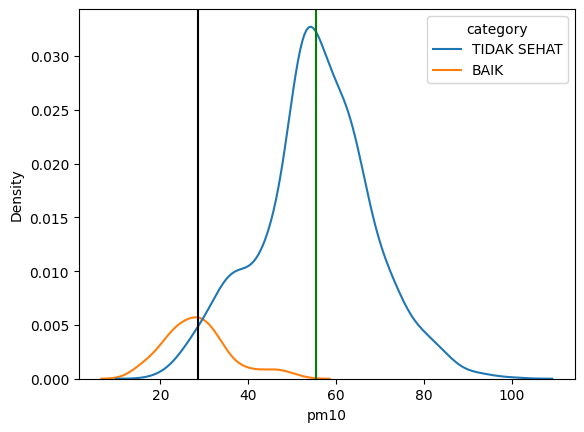

In [14]:
# pm10 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "pm10",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["pm10"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["pm10"].mean(), 0, 1, color='k')
plt.show()

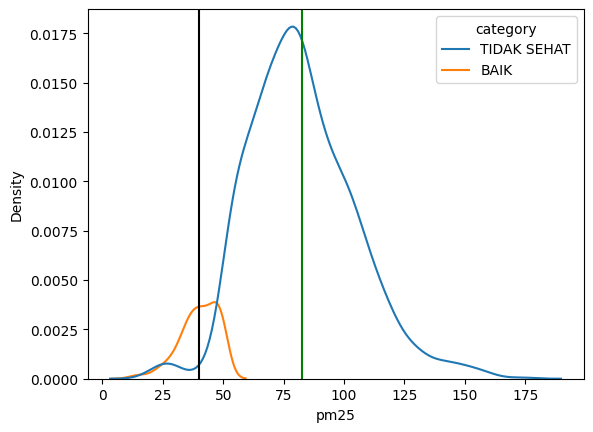

In [15]:
# pm25 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "pm25",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["pm25"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["pm25"].mean(), 0, 1, color='k')
plt.show()

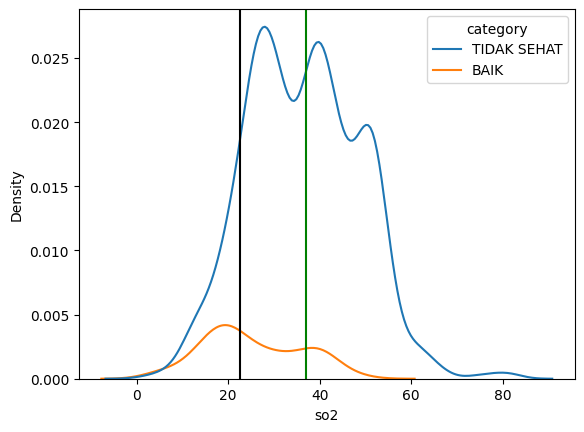

In [16]:
# so2 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "so2",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["so2"].median(), 0, 1, color='g')
plt.axvline(dataset_baik["so2"].median(), 0, 1, color='k')
plt.show()

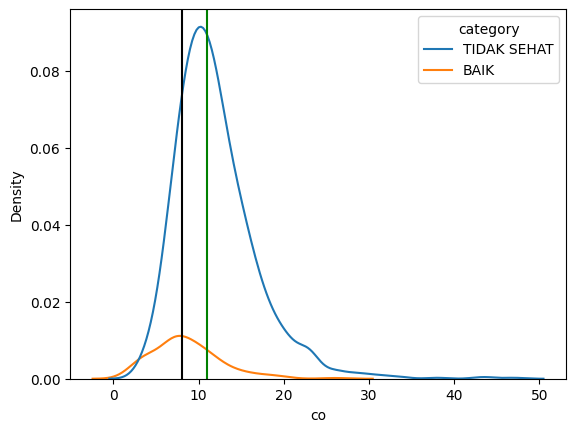

In [17]:
# co column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "co",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["co"].median(), 0, 1, color='g')
plt.axvline(dataset_baik["co"].median(), 0, 1, color='k')
plt.show()

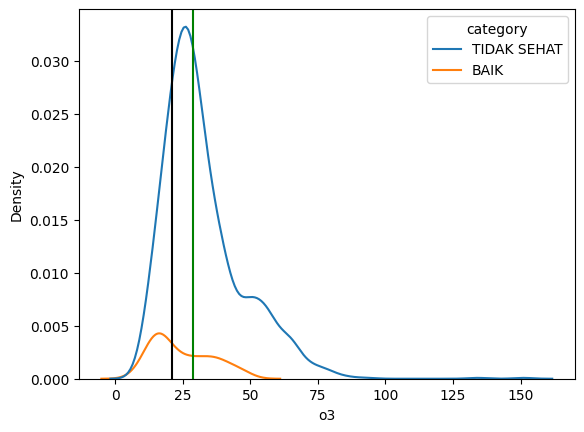

In [18]:
# o3 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "o3",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["o3"].median(), 0, 1, color='g')
plt.axvline(dataset_baik["o3"].median(), 0, 1, color='k')
plt.show()

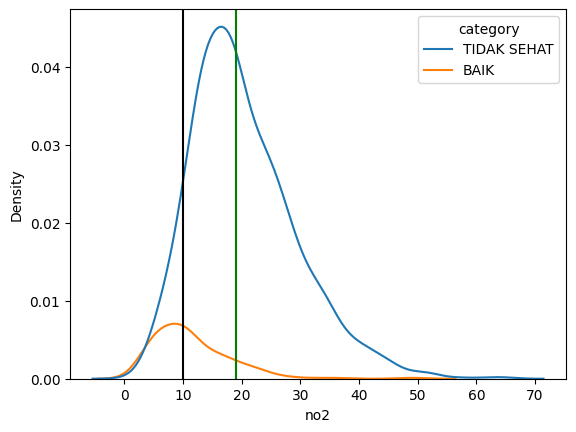

In [19]:
# no2 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "no2",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["no2"].median(), 0, 1, color='g')
plt.axvline(dataset_baik["no2"].median(), 0, 1, color='k')
plt.show()

Coba Cek Korelasinya !

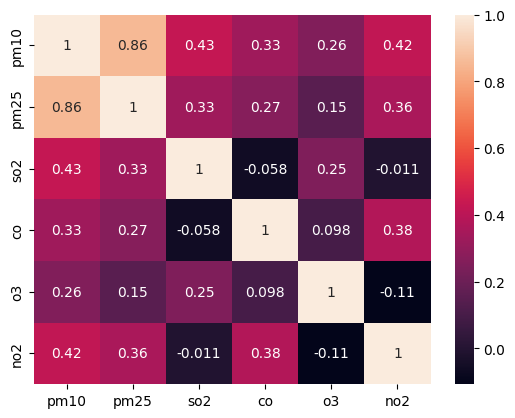

In [20]:
# Pearson Correlation.
sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True
)
plt.show()

## **3.5 Hypothesis Test**
---
T-Test (to check mean between 2 variables)

Note:

- h0 (null hypothesis): mean of class 0 == mean of class 1.
- h1 (alternative hypothesis): mean of class 0 != mean of class 1.
- h0 and h1 is mutually exclusive (if h0 is true, h1 is false, and vice versa).
- The goal of the test is to determine whether to reject the h0
.

In [21]:
# pm10 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["pm10"].isnull() != True].pm10,
    dataset_tidak_baik[dataset_tidak_baik["pm10"].isnull() != True].pm10
)

TtestResult(statistic=np.float64(-24.701711303402124), pvalue=np.float64(3.7581401705556475e-112), df=np.float64(1403.0))

In [22]:
# t-critical for alpha=0.05 and dof=n-2
scs.t.ppf(0.05, df=(len(dataset) - 2))

np.float64(-1.6459066313849768)

Insights:

- If tvalue < tcritical and Pvalue < 0.05 then h0 is rejected
- Summary: pm10 mean between class 0 and class 1 is statistically significant

In [23]:
# pm25 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["pm25"].isnull() != True].pm25,
    dataset_tidak_baik[dataset_tidak_baik["pm25"].isnull() != True].pm25
)

TtestResult(statistic=np.float64(-20.69660238218254), pvalue=np.float64(3.906253615418468e-83), df=np.float64(1386.0))

In [24]:
# so2 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["so2"].isnull() != True].so2,
    dataset_tidak_baik[dataset_tidak_baik["so2"].isnull() != True].so2
)

TtestResult(statistic=np.float64(-10.571557117798413), pvalue=np.float64(3.610151198684074e-25), df=np.float64(1377.0))

In [25]:
# co t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["co"].isnull() != True].co,
    dataset_tidak_baik[dataset_tidak_baik["co"].isnull() != True].co
)

TtestResult(statistic=np.float64(-8.299770674873841), pvalue=np.float64(2.3776714767201342e-16), df=np.float64(1436.0))

In [26]:
# o3 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["o3"].isnull() != True].o3,
    dataset_tidak_baik[dataset_tidak_baik["o3"].isnull() != True].o3
)

TtestResult(statistic=np.float64(-6.2915463633114115), pvalue=np.float64(4.1864486471299125e-10), df=np.float64(1409.0))

In [27]:
# no2 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["no2"].isnull() != True].no2,
    dataset_tidak_baik[dataset_tidak_baik["no2"].isnull() != True].no2
)

TtestResult(statistic=np.float64(-11.619522706475223), pvalue=np.float64(6.845047709459027e-30), df=np.float64(1433.0))

## **3.6. Imbalanced Label Check** 
---

In [28]:
# Check the proportion of the label.
dataset["category"].value_counts(normalize=True)

category
SEDANG         0.720000
TIDAK SEHAT    0.175862
BAIK           0.104138
Name: proportion, dtype: float64

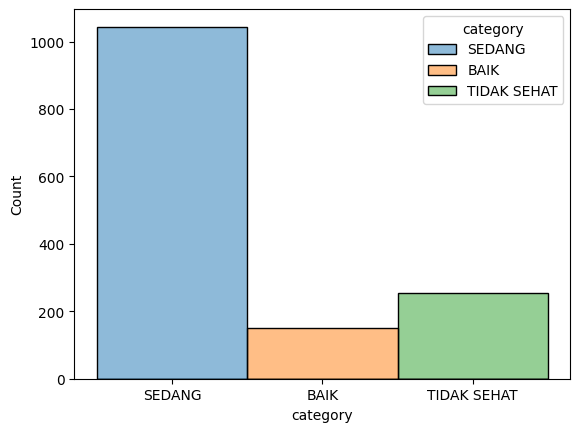

In [29]:
sns.histplot(
    data = dataset,
    x = "category",
    hue="category"
)
plt.show()

## **3.7. Outliers Check** 
---

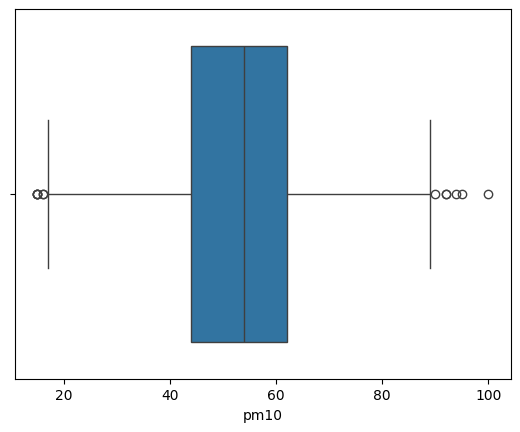

In [30]:
# pm10 boxplot.
sns.boxplot(
    data = dataset,
    x = "pm10"
)
plt.show()

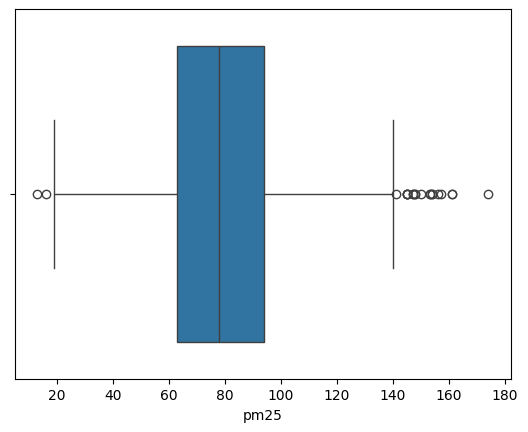

In [31]:
# pm25 boxplot.
sns.boxplot(
    data = dataset,
    x = "pm25"
)
plt.show()

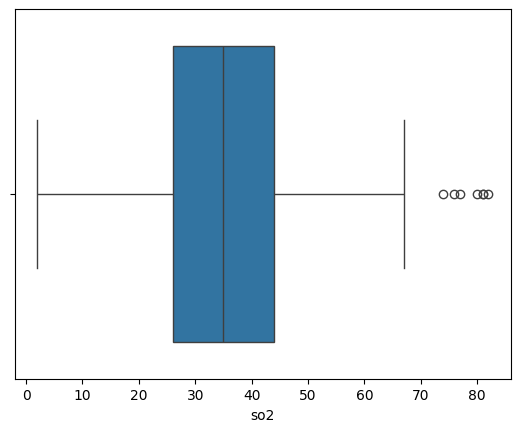

In [32]:
# so2 boxplot.
sns.boxplot(
    data = dataset,
    x = "so2"
)
plt.show()

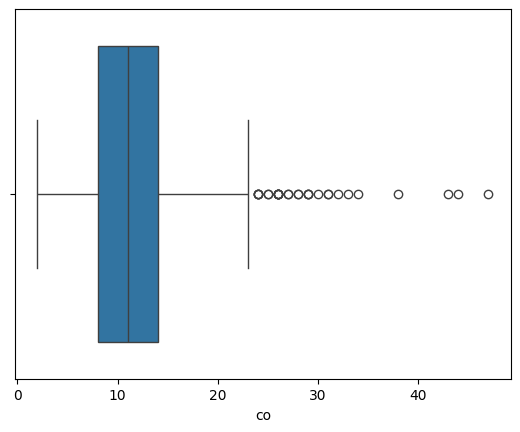

In [33]:
# co boxplot.
sns.boxplot(
    data = dataset,
    x = "co"
)
plt.show()

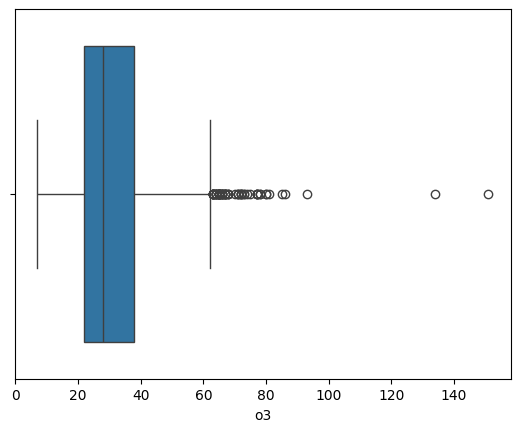

In [34]:
# o3 boxplot.
sns.boxplot(
    data = dataset,
    x = "o3"
)
plt.show()

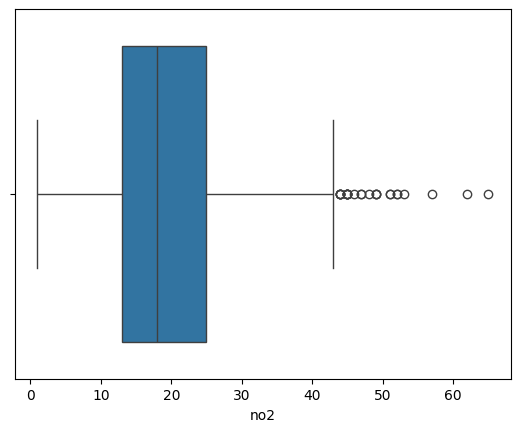

In [35]:
# no2 boxplot.
sns.boxplot(
    data = dataset,
    x = "no2"
)
plt.show()

Summary:

1. Missing Value Handling
   - pm10 and pm25 : class mean
   - so2 : mean
   - co, o3, and no2 : median
2. Join label SEDANG and TIDAK SEHAT into TIDAK BAIK
3. Label balancing BAIK and TIDAK BAIK
4. Outliers removal
